<!-- <!-- [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/VectorInstitute/interpretability/blob/main/implementations/Post-hoc/SHAP/shap-nn-jupyter.ipynb)
 -->
# SHAP for Neural Network Models -->

<!-- ## **1. Introduction**

SHAP is model-agnostic and can be used to explain other black box models as well, for example, neural networks.
The shap module in python has something called KernelExplainer which can be used for NNs.

Let's illustrate this using a [Credit Card Defaulter dataset from Taiwan](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)

The dataset has the following 23 variables as explanatory variables:
| Variable | Description |
|----------|------------|
| LIMIT_BAL  | Amount of the given credit (NT dollar): includes both individual consumer credit and family (supplementary) credit. |
| SEX  | Gender (1 = male; 2 = female). |
| EDUCATION  | Education (1 = graduate school; 2 = university; 3 = high school; 4 = others). |
| MARRIAGE  | Marital status (1 = married; 2 = single; 3 = others). |
| AGE  | Age (years). |
| PAY_0  | Repayment status in September 2005 (-1 = pay duly; 1 = delay for 1 month; 2 = delay for 2 months; ...; 8 = delay for 8 months; 9 = delay for 9+ months). |
|  PAY_2 | Repayment status in August 2005. |
| PAY_3  | Repayment status in July 2005. |
| PAY_4  | Repayment status in June 2005. |
| PAY_5 | Repayment status in May 2005. |
| PAY_6 | Repayment status in April 2005. |
| BILL_AMT1 | Amount of bill statement (NT dollar) in September 2005. |
| BILL_AMT2 | Amount of bill statement (NT dollar) in August 2005. |
| BILL_AMT3 | Amount of bill statement (NT dollar) in July 2005. |
| BILL_AMT4 | Amount of bill statement (NT dollar) in June 2005. |
| BILL_AMT5 | Amount of bill statement (NT dollar) in May 2005. |
| BILL_AMT6 | Amount of bill statement (NT dollar) in April 2005. |
| PAY_AMT1 | Amount of previous payment (NT dollar) in September 2005. |
| PAY_AMT2 | Amount of previous payment (NT dollar) in August 2005. |
| PAY_AMT3 | Amount of previous payment (NT dollar) in July 2005. |
| PAY_AMT4 | Amount of previous payment (NT dollar) in June 2005. |
| PAY_AMT5 | Amount of previous payment (NT dollar) in May 2005. |
| PAY_AMT6 | Amount of previous payment (NT dollar) in April 2005. | -->

<!-- ## **2. Import the necessary libraries** -->

In [ ]:
import numpy as np
import pandas as pd
import shap
import torch
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset


np.random.seed(1)

<!-- ## **3. Loading the dataset** -->

In [ ]:
# !curl -o data/clients.zip https://archive.ics.uci.edu/static/public/350/default+of+credit+card+clients.zip
# !unzip -o data/clients.zip -d data
# !rm data/clients.zip

In [ ]:
# Load the data
data = pd.read_excel(
    "data/default of credit card clients.xls",
    header=1,
)
data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


<!-- ## **4. Create a PyTorch dataset**
Create a dataset class inherited from PyTorch Dataset to be input for model training. -->

In [ ]:
# Load dataset
X = data.drop(["default payment next month", "ID"], axis=1)
y = data["default payment next month"]

# Scale the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
y_train = y_train.values  # Convert pandas series to NumPy array
y_test = y_test.values


# Create a PyTorch Dataset
class CreditDataset(Dataset):
    """PyTorch Dataset for Credit data."""

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)  # Reshape y to be column vector

    def __len__(self):
        """Return dataset length."""
        return len(self.X)

    def __getitem__(self, idx):
        """Get item at index."""
        return self.X[idx], self.y[idx]


# Create DataLoaders for batching
batch_size = 64
train_dataset = CreditDataset(X_train, y_train)
test_dataset = CreditDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

<!-- ## **5. Train a 3-layer MLP using PyTorch**
Let's train a simple 3-layer MLP to predict credit card defaults. -->

Epoch [10/125], Loss: 0.4292
Epoch [20/125], Loss: 0.4223
Epoch [30/125], Loss: 0.4173
Epoch [40/125], Loss: 0.4139
Epoch [50/125], Loss: 0.4107
Epoch [60/125], Loss: 0.4074
Epoch [70/125], Loss: 0.4054
Epoch [80/125], Loss: 0.4016
Epoch [90/125], Loss: 0.3985
Epoch [100/125], Loss: 0.3968
Epoch [110/125], Loss: 0.3944
Epoch [120/125], Loss: 0.3925
Accuracy: 0.8098
ROC AUC Score: 0.7636


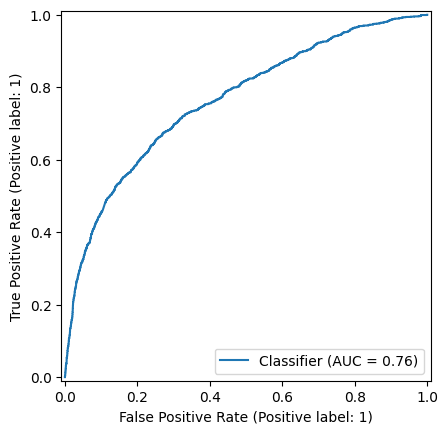

In [ ]:
# Define the model
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 1),
    nn.Sigmoid(),
)

# Loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model in batches
num_epochs = 125
for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Print average loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

# Evaluate the model
model.eval()  # Set model to evaluation mode
y_pred_probs = []
y_true = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        y_pred_probs.extend(outputs.numpy())  # Store predictions
        y_true.extend(batch_y.numpy())  # Store true labels

# Convert predictions to NumPy array
y_pred_probs = np.array(y_pred_probs).flatten()
y_true = np.array(y_true).flatten()

# Compute accuracy
accuracy = ((y_pred_probs > 0.5) == y_true).mean()
print(f"Accuracy: {accuracy:.4f}")

# Compute ROC AUC score
roc_auc = roc_auc_score(y_true, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Plot ROC curve
RocCurveDisplay.from_predictions(y_true, y_pred_probs)

<!-- ## **6. Use SHAP to explain Neural network predictions** -->

In [ ]:
# Use existing NumPy arrays
X_train_np = X_train
X_test_np = X_test

# Reduce background dataset for SHAP (using 200 samples instead of full training set)
background = shap.kmeans(X_train_np, 200)


# Wrapper function for PyTorch model inference
def model_wrapper(data):
    """Model wrapper for SHAP."""
    with torch.no_grad():
        data_tensor = torch.tensor(data, dtype=torch.float32)
        return model(data_tensor).detach().numpy()
        # Should be (n_samples, n_classes)

# Use KernelExplainer with reduced background
explainer = shap.KernelExplainer(model_wrapper, background)


# Explain only a small subset of the test set (e.g., 50 samples)
X_test_sample = X_test_np[:50]


# Compute SHAP values
shap_values = explainer.shap_values(X_test_sample)

print("X_test_sample shape:", X_test_sample.shape)  # Should be (n_samples, n_features)
print("SHAP values shape:", np.array(shap_values).shape)  # Should match (n_samples, n_features)

# Remove extra dimension if shap_values is (50, 23, 1)
shap_values = np.array(shap_values)  # Convert to NumPy array
if shap_values.shape[-1] == 1:
    shap_values = shap_values.squeeze(-1)  # Remove last dimension

# Ensure correct shape
print("Updated SHAP values shape:", shap_values.shape)  # Should be (50, 23)


# Generate SHAP summary plot
# shap.summary_plot(shap_values, X_test_sample, feature_names=data.columns[1:-1])

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/50 [00:00<?, ?it/s]

X_test_sample shape: (50, 23)
SHAP values shape: (50, 23, 1)
Updated SHAP values shape: (50, 23)


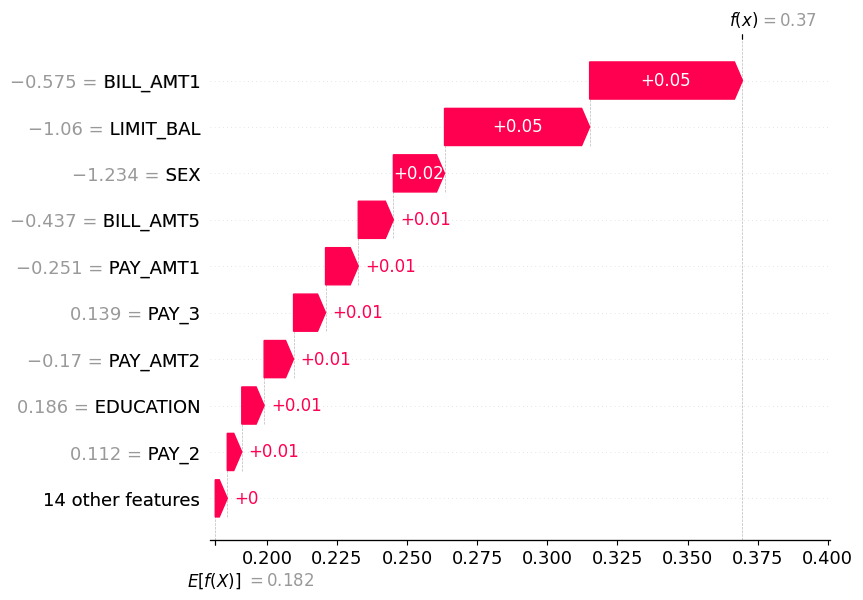

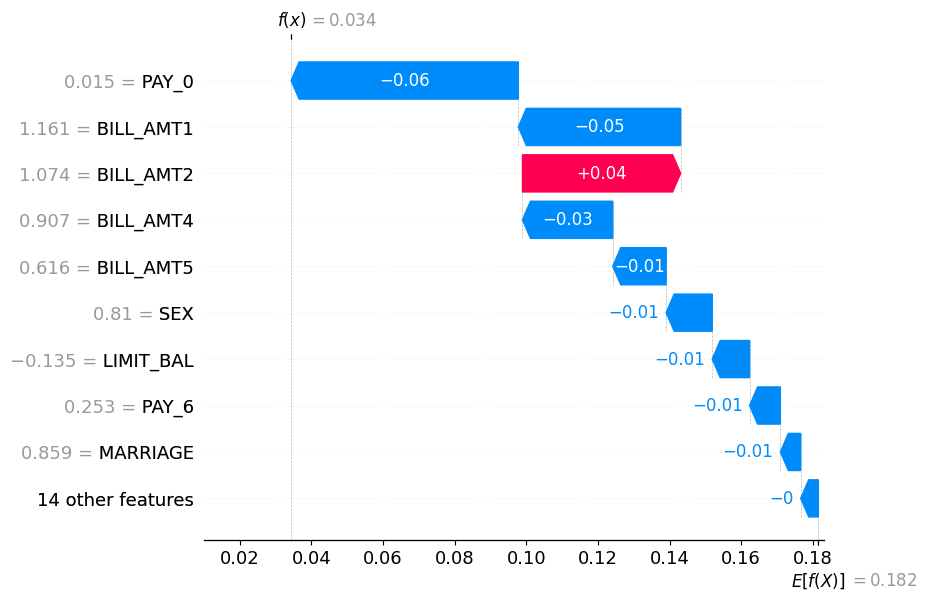

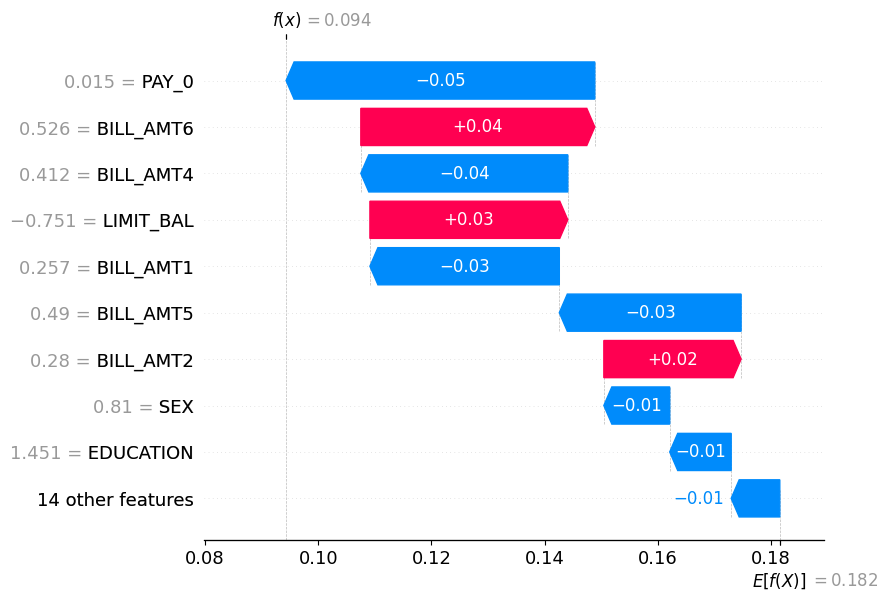

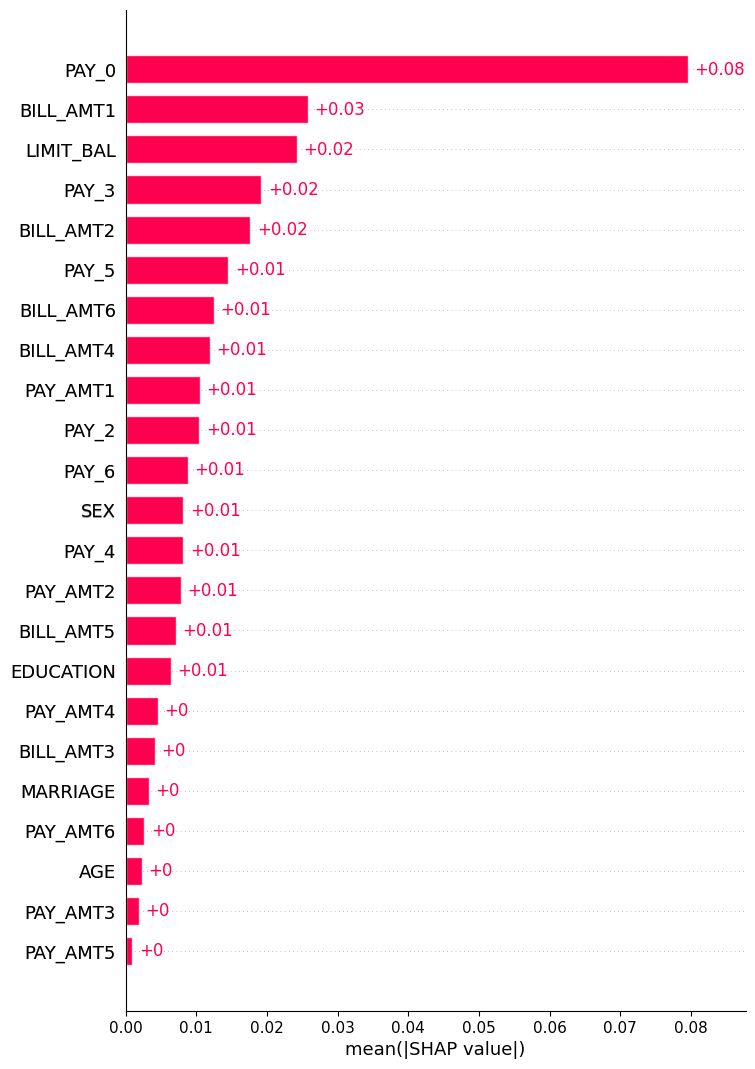

In [ ]:
# Initialize SHAP JavaScript
shap.initjs()

# Create explanation object
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value[0],  # Use scalar
    data=X_test_sample,
    feature_names=list(data.columns[1:-1])
)

# Waterfall plots for first 3 samples
for i in range(3):
    shap.plots.waterfall(explanation[i])

# Global feature importance plot
shap.plots.bar(explanation, max_display=30)

<!-- # Reflection & Concept Check

#### 1. Thought Experiment

**How might correlated features affect SHAP interpretations?**

**Answer:**

KernelSHAP approximates Shapley values by sampling feature coalitions and implicitly assumes feature independence when marginalizing missing features.
If features are correlated (e.g., `BILL_AMT1–6`):

* Importance may be **distributed across correlated features**
* Attribution may appear diluted
* Removing one correlated feature may not change prediction much (since others substitute)

This can:

* Underestimate true causal importance
* Make rankings unstable
* Produce misleading interpretations

In financial datasets, repayment and bill history are strongly correlated, so SHAP values reflect predictive contribution under independence assumptions, not causal effect. -->

In [ ]:
# Compute correlation matrix
X_train_df = pd.DataFrame(X_train, columns=data.columns[1:-1])
correlation_matrix = X_train_df.corr()
# print(correlation_matrix)

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Create correlation heatmap with feature names
# plt.figure(figsize=(14, 12))
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
#             xticklabels=True, yticklabels=True)
# plt.title('Feature Correlation Matrix')
# plt.tight_layout()
# plt.show()

In [ ]:
# Find pairs with correlation > 0.7
def find_high_correlations(corr_matrix, threshold=0.7):
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                high_corr_pairs.append({
                    'Feature 1': corr_matrix.columns[i],
                    'Feature 2': corr_matrix.columns[j],
                    'Correlation': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(high_corr_pairs)

high_corr = find_high_correlations(correlation_matrix, threshold=0.7)
print(high_corr.sort_values('Correlation', ascending=False, key=abs))

    Feature 1  Feature 2  Correlation
5   BILL_AMT1  BILL_AMT2     0.951598
19  BILL_AMT5  BILL_AMT6     0.946754
17  BILL_AMT4  BILL_AMT5     0.938511
10  BILL_AMT2  BILL_AMT3     0.925135
14  BILL_AMT3  BILL_AMT4     0.918356
18  BILL_AMT4  BILL_AMT6     0.900838
11  BILL_AMT2  BILL_AMT4     0.890216
6   BILL_AMT1  BILL_AMT3     0.888002
15  BILL_AMT3  BILL_AMT5     0.878807
12  BILL_AMT2  BILL_AMT5     0.859068
7   BILL_AMT1  BILL_AMT4     0.855804
16  BILL_AMT3  BILL_AMT6     0.850489
13  BILL_AMT2  BILL_AMT6     0.830404
8   BILL_AMT1  BILL_AMT5     0.827622
2       PAY_4      PAY_5     0.820118
4       PAY_5      PAY_6     0.814612
9   BILL_AMT1  BILL_AMT6     0.800231
1       PAY_3      PAY_4     0.777305
0       PAY_2      PAY_3     0.768607
3       PAY_4      PAY_6     0.715312


In [ ]:
# Create a drop list based on high correlations
features_to_drop = []

# Find highly correlated pairs and keep only one from each pair
for _, row in high_corr.iterrows():
    # Drop the second feature from each pair to avoid duplicates
    if row['Feature 2'] not in features_to_drop:
        features_to_drop.append(row['Feature 2'])

print("Features to drop:", features_to_drop)

# Get feature names
feature_names = list(data.columns[1:-1])
print(f"Original features: {len(feature_names)}")
print(f"Dropping {len(features_to_drop)} features")

# Get indices of features to drop
drop_indices = [i for i, col in enumerate(feature_names) if col in features_to_drop]

# Remove correlated features from training and test data
X_train_reduced = np.delete(X_train, drop_indices, axis=1)
X_test_reduced = np.delete(X_test, drop_indices, axis=1)
X_test_sample_reduced = np.delete(X_test_sample, drop_indices, axis=1)

# Get remaining feature names
remaining_features = [col for col in feature_names if col not in features_to_drop]

print(f"Reduced features: {len(remaining_features)}")
print("Remaining features:", remaining_features)

Features to drop: ['PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
Original features: 23
Dropping 9 features
Reduced features: 14
Remaining features: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'BILL_AMT1', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [ ]:
# Retrain model with reduced features
model_reduced = nn.Sequential(
    nn.Linear(X_train_reduced.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 1),
    nn.Sigmoid(),
)

# Loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model_reduced.parameters(), lr=0.001)

# Create datasets with reduced features
train_dataset_reduced = CreditDataset(X_train_reduced, y_train)
test_dataset_reduced = CreditDataset(X_test_reduced, y_test)

train_loader_reduced = DataLoader(train_dataset_reduced, batch_size=64, shuffle=True)
test_loader_reduced = DataLoader(test_dataset_reduced, batch_size=64, shuffle=False)

# Train the reduced model
num_epochs = 125
for epoch in range(num_epochs):
    model_reduced.train()
    running_loss = 0.0
    
    for batch_x, batch_y in train_loader_reduced:
        optimizer.zero_grad()
        outputs = model_reduced(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        avg_loss = running_loss / len(train_loader_reduced)
        # print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

# Evaluate reduced model
model_reduced.eval()
y_pred_probs_reduced = []
with torch.no_grad():
    for batch_x, _ in test_loader_reduced:
        outputs = model_reduced(batch_x)
        y_pred_probs_reduced.extend(outputs.numpy())

y_pred_probs_reduced = np.array(y_pred_probs_reduced).flatten()
accuracy_reduced = ((y_pred_probs_reduced > 0.5) == y_test).mean()
roc_auc_reduced = roc_auc_score(y_test, y_pred_probs_reduced)
print(f"Reduced Model Accuracy: {accuracy_reduced:.4f}")
print(f"Reduced Model ROC AUC Score: {roc_auc_reduced:.4f}")

Reduced Model Accuracy: 0.8118
Reduced Model ROC AUC Score: 0.7608


Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_7796/1182074343.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_reduced, X_test_sample_reduced, feature_names=remaining_features)


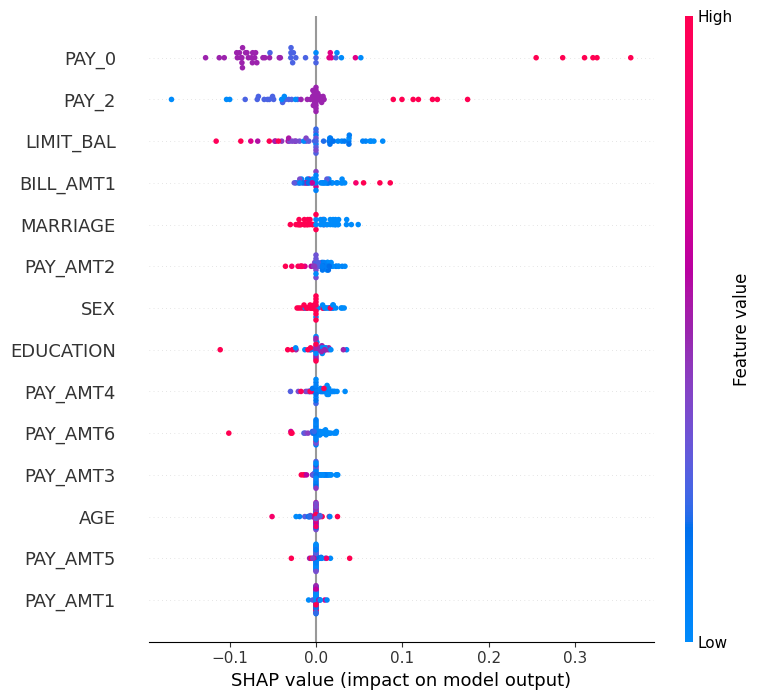

In [ ]:
# Wrapper for reduced model
def model_wrapper_reduced(data):
    with torch.no_grad():
        data_tensor = torch.tensor(data, dtype=torch.float32)
        return model_reduced(data_tensor).detach().numpy()

# Create SHAP explainer with reduced model
explainer_reduced = shap.KernelExplainer(model_wrapper_reduced, shap.kmeans(X_train_reduced, 200))

# Compute SHAP values
shap_values_reduced = explainer_reduced.shap_values(X_test_sample_reduced)
shap_values_reduced = np.array(shap_values_reduced).squeeze(-1) if np.array(shap_values_reduced).shape[-1] == 1 else shap_values_reduced

# Summary plot
shap.summary_plot(shap_values_reduced, X_test_sample_reduced, feature_names=remaining_features)

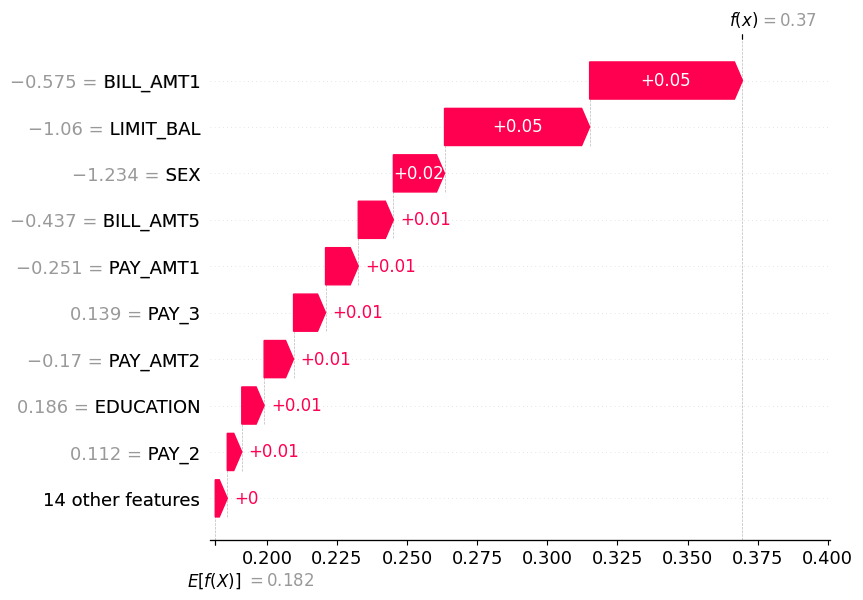

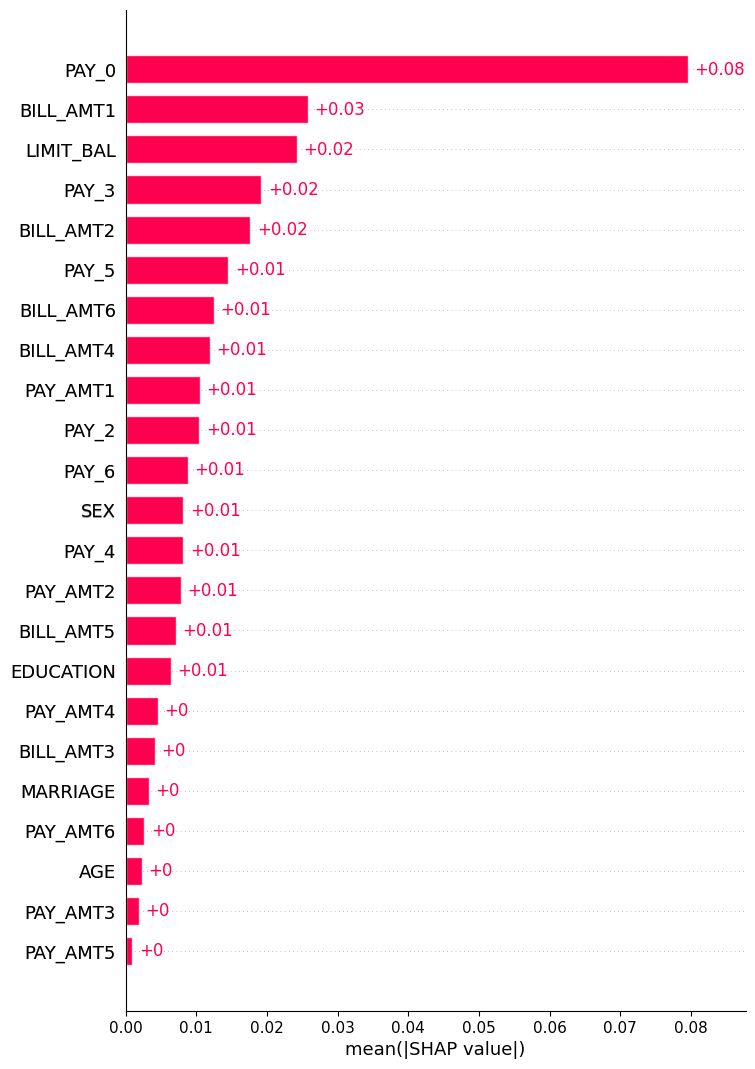

In [ ]:
# Create explanation object
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value[0],  # Use scalar
    data=X_test_sample,
    feature_names=list(data.columns[1:-1])
)

shap.plots.waterfall(explanation[0])

shap.plots.bar(explanation, max_display=30)

<!-- # Final Model - Remove the sigmoid layer, SHAP on logits -->

THOUGHT EXPERIMENT 5: SHAP on Logits (Removing Sigmoid Layer)

1. Creating SHAP explainers...
   ✓ Explainers created

2. Computing SHAP values...


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

   ✓ SHAP values computed

3. Output Comparison (First 5 Samples):
Sample   Logits          Probability     SHAP Sum (Logits)    SHAP Sum (Probs)    
   --------------------------------------------------------------------------------
   0               -1.3480         0.2062              0.5508              0.0238
   1               -2.4868         0.0768             -0.5881             -0.1056
   2               -2.1585         0.1035             -0.2597             -0.0788
   3               -2.3948         0.0836             -0.4960             -0.0988
   4               -1.3477         0.2062              0.5510              0.0239

4. Key Differences Between Logits and Probabilities:

   A. RANGE OF VALUES:
      Logits SHAP range:        [-1.6739, 1.9747]
      Probabilities SHAP range: [-0.1653, 0.3877]
      → Logit values are UNBOUNDED, probabilities are constrained [0,1]

   B. ADDITIVITY CHECK:
      Base value (logits):       -1.8988
      Base value (probabilities): 0.1824

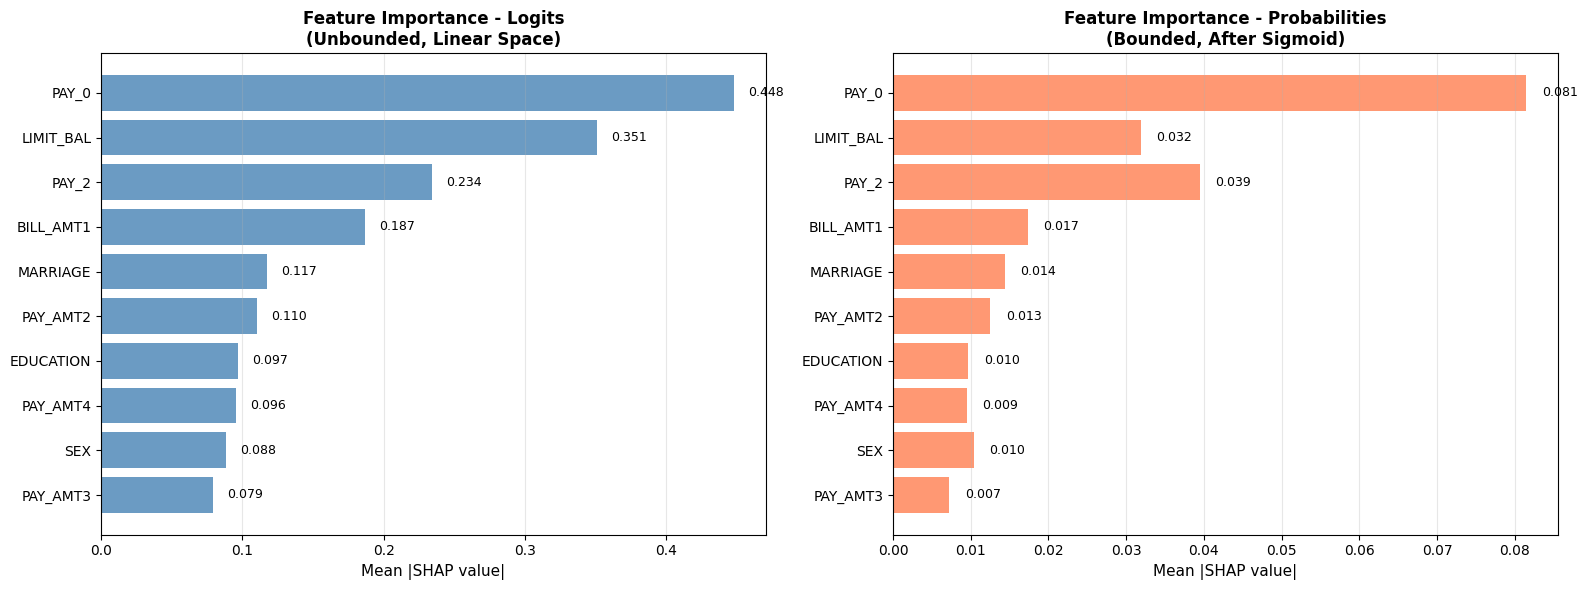

   ✓ Comparison plot saved


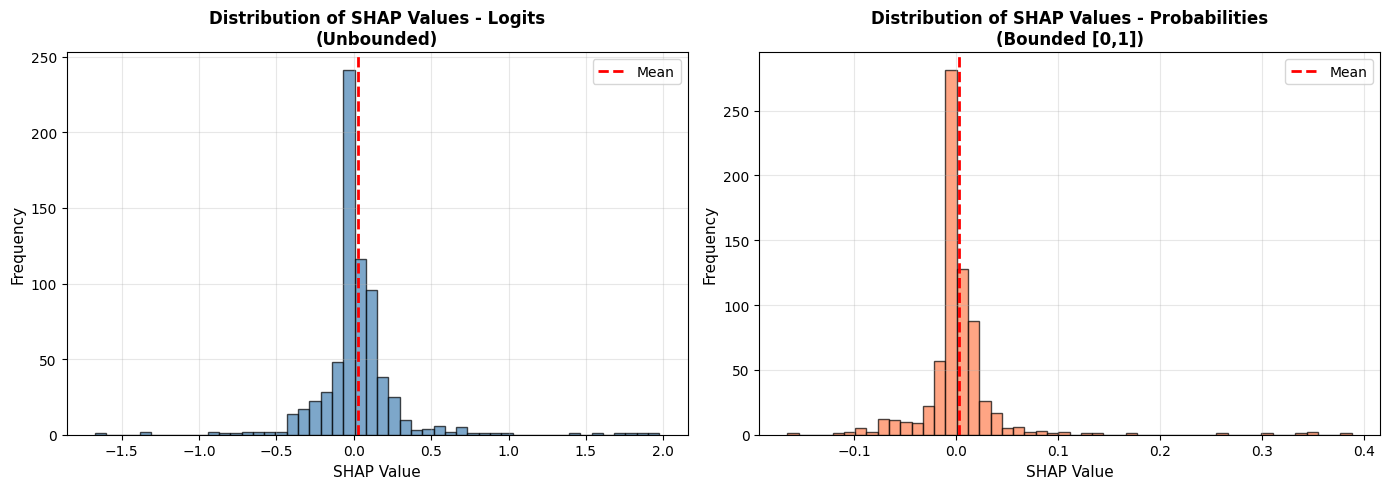

   ✓ Distribution plot saved

SUMMARY: Why SHAP on Logits is Mathematically Superior

MODEL STRUCTURE USED:
├─ [0] Linear(n_features, 64)
├─ [1] ReLU()
├─ [2] Linear(64, 32)
├─ [3] ReLU()
├─ [4] Dropout(0.3)
├─ [5] Linear(32, 1)  ← LOGITS OUTPUT (stop here)
└─ [6] Sigmoid()      ← REMOVED for logits computation

KEY MATHEMATICAL DIFFERENCES:

1. ADDITIVITY (CRITICAL):
   ✓ Logits:       output = base + Σφᵢ  [EXACT in linear space]
   ✗ Probs:        sigmoid(base + Σφᵢ)  [Approximate due to nonlinearity]

2. VALUE RANGES:
   • Logits SHAP:  [-∞, +∞]  Unbounded, full expressiveness
   • Probs SHAP:   [0, 1]    Compressed, limited range

3. INTERPRETATION STABILITY:
   • Logits:       No saturation effects, stable contributions
   • Probs:        Sigmoid saturation can obscure importance

4. PRACTICAL BENEFITS:
   ✓ Cleaner mathematical decomposition
   ✓ More stable sensitivity analysis
   ✓ Better for feature interaction studies
   ✓ No artificial compression of values

5. WHEN TO USE W

In [ ]:
# ============================================================================
# SHAP on Logits (without sigmoid layer)
# Using model_reduced structure as template
# ============================================================================

import torch
import numpy as np
import shap
import matplotlib.pyplot as plt

print("=" * 80)
print("THOUGHT EXPERIMENT 5: SHAP on Logits (Removing Sigmoid Layer)")
print("=" * 80)

# ============================================================================
# Step 1: Model structure reference
# ============================================================================

# print("\nmodel_reduced structure:")
# print(model_reduced)

# print("\nModel layers breakdown:")
# for i, layer in enumerate(model_reduced):
#     print(f"  [{i}] {layer}")

# ============================================================================
# Step 2: Create model wrapper that outputs logits
# ============================================================================

def model_wrapper_logits(data):
    """
    Outputs logits by stopping before sigmoid (layer 6).
    Structure: [0-5] layers (exclude Sigmoid at [6])
    """
    with torch.no_grad():
        data_tensor = torch.tensor(data, dtype=torch.float32)
        
        # Forward through layers 0-5 (all except Sigmoid)
        x = data_tensor
        for i in range(6):  # 0 to 5 (excludes Sigmoid at index 6)
            x = model_reduced[i](x)
        
        return x.detach().numpy()


def model_wrapper_probabilities(data):
    """
    Outputs probabilities using full model with sigmoid.
    """
    with torch.no_grad():
        data_tensor = torch.tensor(data, dtype=torch.float32)
        return model_reduced(data_tensor).detach().numpy()


# ============================================================================
# Step 3: Create SHAP explainers
# ============================================================================

print("\n1. Creating SHAP explainers...")

background_data = shap.kmeans(X_train_reduced, 100)

explainer_logits = shap.KernelExplainer(model_wrapper_logits, background_data)
explainer_probs = shap.KernelExplainer(model_wrapper_probabilities, background_data)

print("   ✓ Explainers created")

# ============================================================================
# Step 4: Compute SHAP values
# ============================================================================

print("\n2. Computing SHAP values...")

shap_values_logits = explainer_logits.shap_values(X_test_sample_reduced)
shap_values_logits = np.array(shap_values_logits).squeeze()

shap_values_probs = explainer_probs.shap_values(X_test_sample_reduced)
shap_values_probs = np.array(shap_values_probs).squeeze()

print("   ✓ SHAP values computed")

# ============================================================================
# Step 5: Output comparison
# ============================================================================

print("\n3. Output Comparison (First 5 Samples):")
print("   " + "=" * 80)

logits_output = model_wrapper_logits(X_test_sample_reduced[:5])
probs_output = model_wrapper_probabilities(X_test_sample_reduced[:5])

print(f"{'Sample':<8} {'Logits':<15} {'Probability':<15} {'SHAP Sum (Logits)':<20} {'SHAP Sum (Probs)':<20}")
print("   " + "-" * 80)

for i in range(5):
    logit_val = logits_output[i, 0]
    prob_val = probs_output[i, 0]
    shap_sum_logits = np.sum(shap_values_logits[i])
    shap_sum_probs = np.sum(shap_values_probs[i])
    
    print(f"   {i:<8} {logit_val:>14.4f} {prob_val:>14.4f} {shap_sum_logits:>19.4f} {shap_sum_probs:>19.4f}")

print("   " + "=" * 80)

# ============================================================================
# Step 6: Key differences analysis
# ============================================================================

print("\n4. Key Differences Between Logits and Probabilities:")
print("   " + "=" * 80)

print("\n   A. RANGE OF VALUES:")
print(f"      Logits SHAP range:        [{np.min(shap_values_logits):.4f}, {np.max(shap_values_logits):.4f}]")
print(f"      Probabilities SHAP range: [{np.min(shap_values_probs):.4f}, {np.max(shap_values_probs):.4f}]")
print(f"      → Logit values are UNBOUNDED, probabilities are constrained [0,1]")

print("\n   B. ADDITIVITY CHECK:")
print(f"      Base value (logits):       {explainer_logits.expected_value[0]:.4f}")
print(f"      Base value (probabilities): {explainer_probs.expected_value[0]:.4f}")

# Verify additivity for sample 0
sample_idx = 0
logit_reconstruction = explainer_logits.expected_value[0] + np.sum(shap_values_logits[sample_idx])
actual_logit = logits_output[sample_idx, 0]

print(f"\n      Sample {sample_idx} (Logits - Perfect Linear Decomposition):")
print(f"        Base value + SHAP sum = {explainer_logits.expected_value[0]:.4f} + {np.sum(shap_values_logits[sample_idx]):.4f}")
print(f"                              = {logit_reconstruction:.4f}")
print(f"        Actual logit output   = {actual_logit:.4f}")
print(f"        Reconstruction error  = {abs(logit_reconstruction - actual_logit):.8f}")
print(f"      ✓ PERFECT additivity in log-odds space (linear before sigmoid)")

print("\n   C. FEATURE CONTRIBUTION BOUNDS:")
print(f"      Logits (max |SHAP|):       {np.max(np.abs(shap_values_logits)):.4f} (unbounded)")
print(f"      Probabilities (max |SHAP|): {np.max(np.abs(shap_values_probs)):.4f} (bounded by 0-1)")

print("   " + "=" * 80)

# ============================================================================
# Step 7: Visualization - Feature Importance Comparison
# ============================================================================

print("\n5. Generating comparison plots...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature importance
feature_importance_logits = np.abs(shap_values_logits).mean(axis=0)
feature_importance_probs = np.abs(shap_values_probs).mean(axis=0)

# Top 10 features by logits importance
sort_idx = np.argsort(feature_importance_logits)[::-1][:10]
feature_names_sorted = [remaining_features[i] for i in sort_idx]

# Plot 1: Logits
ax1 = axes[0]
x_pos = np.arange(len(sort_idx))
bars1 = ax1.barh(x_pos, feature_importance_logits[sort_idx], alpha=0.8, color='steelblue')
ax1.set_yticks(x_pos)
ax1.set_yticklabels(feature_names_sorted, fontsize=10)
ax1.set_xlabel('Mean |SHAP value|', fontsize=11)
ax1.set_title('Feature Importance - Logits\n(Unbounded, Linear Space)', 
              fontweight='bold', fontsize=12)
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, v) in enumerate(zip(sort_idx, feature_importance_logits[sort_idx])):
    ax1.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

# Plot 2: Probabilities
ax2 = axes[1]
bars2 = ax2.barh(x_pos, feature_importance_probs[sort_idx], alpha=0.8, color='coral')
ax2.set_yticks(x_pos)
ax2.set_yticklabels(feature_names_sorted, fontsize=10)
ax2.set_xlabel('Mean |SHAP value|', fontsize=11)
ax2.set_title('Feature Importance - Probabilities\n(Bounded, After Sigmoid)', 
              fontweight='bold', fontsize=12)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, v) in enumerate(zip(sort_idx, feature_importance_probs[sort_idx])):
    ax2.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('shap_logits_vs_probs.png', dpi=100, bbox_inches='tight')
plt.show()

print("   ✓ Comparison plot saved")

# ============================================================================
# Step 8: Distribution comparison
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SHAP value distributions
ax1 = axes[0]
ax1.hist(shap_values_logits.flatten(), bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax1.set_xlabel('SHAP Value', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Distribution of SHAP Values - Logits\n(Unbounded)', fontweight='bold', fontsize=12)
ax1.grid(alpha=0.3)
ax1.axvline(np.mean(shap_values_logits), color='red', linestyle='--', linewidth=2, label='Mean')
ax1.legend()

ax2 = axes[1]
ax2.hist(shap_values_probs.flatten(), bins=50, alpha=0.7, color='coral', edgecolor='black')
ax2.set_xlabel('SHAP Value', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution of SHAP Values - Probabilities\n(Bounded [0,1])', fontweight='bold', fontsize=12)
ax2.grid(alpha=0.3)
ax2.axvline(np.mean(shap_values_probs), color='red', linestyle='--', linewidth=2, label='Mean')
ax2.legend()

plt.tight_layout()
plt.savefig('shap_distribution_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("   ✓ Distribution plot saved")

# ============================================================================
# Step 9: Summary & Interpretation
# ============================================================================

print("\n" + "=" * 80)
print("SUMMARY: Why SHAP on Logits is Mathematically Superior")
print("=" * 80)

summary = """
MODEL STRUCTURE USED:
├─ [0] Linear(n_features, 64)
├─ [1] ReLU()
├─ [2] Linear(64, 32)
├─ [3] ReLU()
├─ [4] Dropout(0.3)
├─ [5] Linear(32, 1)  ← LOGITS OUTPUT (stop here)
└─ [6] Sigmoid()      ← REMOVED for logits computation

KEY MATHEMATICAL DIFFERENCES:

1. ADDITIVITY (CRITICAL):
   ✓ Logits:       output = base + Σφᵢ  [EXACT in linear space]
   ✗ Probs:        sigmoid(base + Σφᵢ)  [Approximate due to nonlinearity]

2. VALUE RANGES:
   • Logits SHAP:  [-∞, +∞]  Unbounded, full expressiveness
   • Probs SHAP:   [0, 1]    Compressed, limited range

3. INTERPRETATION STABILITY:
   • Logits:       No saturation effects, stable contributions
   • Probs:        Sigmoid saturation can obscure importance

4. PRACTICAL BENEFITS:
   ✓ Cleaner mathematical decomposition
   ✓ More stable sensitivity analysis
   ✓ Better for feature interaction studies
   ✓ No artificial compression of values

5. WHEN TO USE WHICH:
   • Model interpretation:     Use LOGITS ✓
   • Report to stakeholders:   Convert logits → probs for communication
   • Feature importance:       Compute on logits, present on probs scale
   • Debugging model:          Always use logits first

RECOMMENDATION:
Always compute SHAP on logits for neural networks with sigmoid output layers.
Convert to probability scale only for final reporting/visualization.
"""

print(summary)
print("=" * 80)

# Store results
results_summary = {
    'explainer_logits': explainer_logits,
    'explainer_probs': explainer_probs,
    'shap_values_logits': shap_values_logits,
    'shap_values_probs': shap_values_probs,
    'base_value_logits': explainer_logits.expected_value[0],
    'base_value_probs': explainer_probs.expected_value[0],
}

print("\n✓ Results stored in 'results_summary' dictionary")

<!-- # Section 8: LLM Summary + Faithful Evaluation Pipeline

This section implements an end-to-end pipeline for:
1. Generating LLM-based global and local SHAP summaries
2. Evaluating faithfulness using automated scoring and LLM-as-judge
3. Testing consistency via perturbation analysis

**Requirements:**
- GEMINI API key set in environment variable `GEMINI_API_KEY`
- Dependencies: `google`, `numpy`, `json`

**Notes:**
- Uses GEMINI model for LLM explanations
- Requires variables from previous cells: `model_reduced`, `explainer_reduced`, `shap_values_reduced`, `X_test_sample_reduced`, `remaining_features` -->


In [ ]:
pip install -U google-genai

In [47]:
# ============================================================
# Step 1: Setup - Imports and Gemini Client and Langfuse
# ============================================================

import json
from google import genai
import numpy as np
import os
from dotenv import load_dotenv
from langfuse import Langfuse
from langfuse import get_client

load_dotenv() 
langfuse = get_client()  # preferred client init

# Initialize Gemini client (reads GEMINI_API_KEY from environment)
client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))
MODEL = "gemini-2.5-flash-lite"
TOP_K = 5  # number of top SHAP features to consider

# Get base value from the explainer
base_value = float(explainer_logits.expected_value)
print(f"Base value (expected model output): {base_value:.4f}")

Base value (expected model output): -1.8988


/tmp/ipykernel_7796/190865875.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  base_value = float(explainer_logits.expected_value)


<!-- ## 8.1 Global SHAP Summary (Zero-Shot Prompting) -->

In [39]:
def build_global_prompt(shap_values, feature_names, base_val, top_k=TOP_K):
    """
    Construct a zero-shot prompt for the global SHAP summary.
    
    Args:
        shap_values: Array of shape (n_samples, n_features)
        feature_names: List of feature names
        base_val: Base value from explainer
        top_k: Number of top features to include
    
    Returns:
        prompt: The constructed prompt string
        ranked: Indices of top-K features by mean |SHAP|
    """
    mean_abs = np.abs(shap_values).mean(axis=0)
    mean_dir = shap_values.mean(axis=0)
    ranked = np.argsort(mean_abs)[::-1]

    rows = []
    for rank, i in enumerate(ranked[:top_k], 1):
        direction = "positive" if mean_dir[i] > 0 else "negative"
        rows.append(
            f"  {rank}. {feature_names[i]}: "
            f"mean |SHAP| = {mean_abs[i]:.4f}, direction = {direction}"
        )
    block = "\n".join(rows)

    prompt = f"""You are an ML interpretability expert reviewing a credit card default \
prediction model (3-layer MLP, binary classification, KernelSHAP, {len(shap_values)} test samples).

Top {top_k} globally important features (mean |SHAP| over test set):
{block}

Base value (expected model output): {base_val:.4f}

Write a concise technical global summary (3 to 5 sentences). Cover:
1. Which features dominate and why this aligns with credit-risk intuition.
2. The direction of influence for each top feature.
3. Any notable patterns (e.g., repayment history vs. credit limit trade-offs).
"""
    return prompt, ranked[:top_k]


def get_global_summary(shap_values, feature_names, base_val):
    """
    Generate a global SHAP summary using Gemini.
    
    Returns:
        summary_text: The LLM-generated summary
        top_idx: Indices of top-K features
    """
    prompt, top_idx = build_global_prompt(shap_values, feature_names, base_val)
    resp = client.models.generate_content(
        model=MODEL,
        contents=prompt)
    return resp.text, top_idx

print("✓ Global summary functions defined")

✓ Global summary functions defined


In [40]:
# ============================================================
# EXECUTE: Test Global Summary
# ============================================================

print("=" * 80)
print("EXECUTING: Global SHAP Summary Generation")
print("=" * 80)

# Generate global summary using LLM
global_summary, global_top_idx = get_global_summary(
    shap_values_logits, remaining_features, base_value
)

print("\nGLOBAL SUMMARY OUTPUT:")
print("-" * 80)
print(global_summary)
print("-" * 80)
print(f"\nTop feature indices: {global_top_idx}")
print(f"Top features: {[remaining_features[i] for i in global_top_idx]}")


EXECUTING: Global SHAP Summary Generation

GLOBAL SUMMARY OUTPUT:
--------------------------------------------------------------------------------
This credit card default model's global feature importance is dominated by **PAY_0**, the most recent payment status, and **LIMIT_BAL**, the credit limit. This aligns with credit risk intuition, as recent repayment behavior and available credit are strong indicators of default likelihood. Notably, **PAY_0** positively influences default predictions, suggesting worse repayment status increases default probability, while a higher **LIMIT_BAL** negatively impacts it, indicating larger credit limits reduce perceived default risk. **PAY_2** also negatively influences default, reinforcing the importance of consistent repayment history. The inclusion of **BILL_AMT1** positively influencing default suggests higher current outstanding balances contribute to default risk, while **MARRIAGE** positively influences it, perhaps indicating specific marital

<!-- ## 8.2 Local SHAP Summary (In-Context Learning) -->

In [ ]:
# Curated few-shot reference examples for in-context learning
ICL_EXAMPLES = """
--- Reference Example 1 ---
Input: PAY_0=+0.18, LIMIT_BAL=-0.09, PAY_2=+0.07, AGE=-0.03, EDUCATION=-0.02
Prediction: 0.72 (high default risk). Base: 0.22.
Explanation: The primary driver of this high-risk prediction (0.72) is PAY_0 (+0.18),
reflecting a significant payment delay in September 2005. PAY_2 (+0.07) reinforces a
pattern of consecutive late payments. LIMIT_BAL (-0.09) and AGE (-0.03) provide a mild
mitigating effect but are insufficient to offset the repayment delay signals.

--- Reference Example 2 ---
Input: PAY_0=-0.15, LIMIT_BAL=+0.11, PAY_2=-0.08, AGE=+0.04, EDUCATION=+0.02
Prediction: 0.08 (low default risk). Base: 0.22.
Explanation: This sample is classified as low-risk (0.08). Timely recent repayment
(PAY_0=-0.15) is the strongest protective factor, substantially reducing default
probability below the base rate. A high credit limit (LIMIT_BAL=+0.11) and on-time
August payment (PAY_2=-0.08) further consolidate a stable repayment profile.
"""


def build_local_prompt(idx, shap_values, feature_names, X_sample, base_val, top_k=TOP_K):
    """
    Construct an in-context learning prompt for a single-sample local SHAP explanation.
    
    Args:
        idx: Sample index
        shap_values: SHAP values array
        feature_names: Feature names
        X_sample: Test sample features
        base_val: Base value from explainer
        top_k: Number of top features
    
    Returns:
        prompt: Constructed ICL prompt
        ranked: Top feature indices
        sv: SHAP values for this sample
        pred: Predicted probability
    """
    sv = shap_values[idx]
    fv = X_sample[idx]
    pred = float(base_val + sv.sum())
    ranked = np.argsort(np.abs(sv))[::-1][:top_k]

    rows = [
        f"  {feature_names[i]}: SHAP={sv[i]:+.4f}, feature value={fv[i]:.4f}"
        for i in ranked
    ]
    block = "\n".join(rows)

    prompt = f"""You are an ML interpretability expert.

Use these reference explanations as a style guide:
{ICL_EXAMPLES}

Now produce a local explanation for the sample below.

Sample index  : {idx}
Base value    : {base_val:.4f}
Prediction    : {pred:.4f}  ({'high' if pred >= 0.5 else 'low'} default risk)
Top {top_k} SHAP contributors:
{block}

Write a concise technical explanation (3 to 5 sentences). Reference each feature's SHAP
value and direction; explain what drives the final prediction.
"""
    return prompt, ranked, sv, pred


def get_local_summary(idx, shap_values, feature_names, X_sample):
    """
    Generate a local SHAP summary for a specific sample using Gemini.
    
    Returns:
        summary_text: The LLM-generated explanation
        top_idx: Top feature indices
        sv: SHAP values for this sample
        pred: Predicted probability
    """
    prompt, top_idx, sv, pred = build_local_prompt(
        idx, shap_values, feature_names, X_sample, base_value
    )
    resp = client.models.generate_content(
        model=MODEL,
        contents=prompt)
    return resp.text, top_idx, sv, pred


print("✓ Local summary functions defined")

✓ Local summary functions defined


In [ ]:
# ============================================================
# EXECUTE: Test Local Summary (Sample 0)
# ============================================================

print("\n" + "=" * 80)
print("EXECUTING: Local SHAP Summary Generation (Sample 0)")
print("=" * 80)

# Generate local explanation for first sample
local_summary_sample0, top_idx_sample0, sv_sample0, pred_sample0 = get_local_summary(
    0, shap_values_logits, remaining_features, X_test_sample_reduced
)

print(f"\nLOCAL SUMMARY OUTPUT (Sample 0):")
print(f"Prediction: {pred_sample0:.4f}")
print("-" * 80)
print(local_summary_sample0)
print("-" * 80)
print(f"\nTop 5 SHAP values for Sample 0:")
for i, idx in enumerate(top_idx_sample0):
    print(f"  {i+1}. {remaining_features[idx]}: SHAP={sv_sample0[idx]:+.4f}")



EXECUTING: Local SHAP Summary Generation (Sample 0)

LOCAL SUMMARY OUTPUT (Sample 0):
Prediction: -1.0359
--------------------------------------------------------------------------------
Prediction: -1.0359 (low default risk). Base: -2.0208.
Explanation: This sample is classified as low-risk (-1.0359), significantly above the base value. The most influential factor is `LIMIT_BAL` (+0.6300), indicating a substantial credit limit, which strongly pushes the prediction towards lower risk. While `PAY_0` (0.0149, -0.3184) suggests a slight recent payment delay, its negative SHAP value mitigates the overall risk less than the positive impact of the credit limit. `BILL_AMT1` (+0.1754) and `PAY_AMT2` (+0.1654) contribute positively to reducing risk, alongside a mild effect from `SEX` (+0.0868).
--------------------------------------------------------------------------------

Top 5 SHAP values for Sample 0:
  1. LIMIT_BAL: SHAP=+0.6300
  2. PAY_0: SHAP=-0.3184
  3. BILL_AMT1: SHAP=+0.1754
  4. 

<!-- ## 8.3 Faithfulness Evaluation -->

In [49]:
# ============================================================
# B1. Automated Scoring
# ============================================================

def automated_score(explanation_text, sv_row, feature_names, top_k=TOP_K):
    """
    Automatically score faithfulness by checking:
      - feature_overlap_rate: fraction of top-K SHAP features mentioned in text
      - direction_accuracy: fraction of mentioned features with correct sign
    
    Returns:
        dict with scoring metrics
    """
    ranked = np.argsort(np.abs(sv_row))[::-1][:top_k]
    top_feats = [feature_names[i] for i in ranked]
    top_dirs = {feature_names[i]: ("positive" if sv_row[i] > 0 else "negative")
                for i in ranked}

    text = explanation_text.lower()
    mentioned = [f for f in top_feats if f.lower() in text]
    overlap = len(mentioned) / top_k

    POS_WORDS = ["positive", "increase", "higher", "raises", "pushes up", "+"]
    NEG_WORDS = ["negative", "decrease", "lower", "reduces", "pushes down", "mitigat"]

    hits = 0
    for feat in mentioned:
        pos = text.find(feat.lower())
        ctx = text[max(0, pos - 60): pos + 80]
        correct = top_dirs[feat]
        if correct == "positive" and any(w in ctx for w in POS_WORDS):
            hits += 1
        elif correct == "negative" and any(w in ctx for w in NEG_WORDS):
            hits += 1

    dir_acc = hits / len(mentioned) if mentioned else 0.0

    return {
        "top_k_features": top_feats,
        "mentioned_features": mentioned,
        "feature_overlap_rate": round(overlap, 3),
        "direction_accuracy": round(dir_acc, 3),
    }


# ============================================================
# B2. Perturbation Consistency Test
# ============================================================

def perturbation_test(idx, X_sample, shap_values, feature_names,
                      explainer, model_wrapper, top_k=TOP_K):
    """
    Test consistency by perturbing the top-SHAP feature and checking:
      - pred_changed: whether model prediction changes significantly
      - shap_consistent: whether feature's SHAP magnitude decreases
    
    Returns:
        dict with perturbation results
    """
    sv = shap_values[idx]
    top_feat_idx = int(np.argmax(np.abs(sv)))
    top_feat_name = feature_names[top_feat_idx]
    original_val = X_sample[idx, top_feat_idx]

    # Perturb opposite to SHAP direction to reduce its contribution
    delta = -2.0 if sv[top_feat_idx] > 0 else +2.0

    X_pert = X_sample.copy()
    X_pert[idx, top_feat_idx] += delta

    # Explicitly extract scalar values
    orig_pred = float(model_wrapper(X_sample[idx: idx + 1]).item())
    pert_pred = float(model_wrapper(X_pert[idx: idx + 1]).item())

    shap_pert = explainer.shap_values(X_pert[idx: idx + 1])
    shap_pert = np.array(shap_pert).squeeze()

    return {
        "sample_idx": idx,
        "perturbed_feature": top_feat_name,
        "original_feature_val": round(float(original_val), 4),
        "perturbation_delta": delta,
        "original_prediction": round(orig_pred, 4),
        "perturbed_prediction": round(pert_pred, 4),
        "original_shap": round(float(sv[top_feat_idx]), 4),
        "perturbed_shap": round(float(shap_pert[top_feat_idx]), 4),
        "prediction_changed": abs(pert_pred - orig_pred) > 0.02,
        "shap_consistent": abs(shap_pert[top_feat_idx]) < abs(sv[top_feat_idx]),
    }


# ============================================================
# B3. LLM-as-Judge
# ============================================================

RUBRIC = """
Score faithfulness on a scale of 1-5:
  5 - All top SHAP features mentioned with correct directions; no hallucinations.
  4 - Most features mentioned correctly; minor omissions or one direction error.
  3 - Some features mentioned; notable omissions or one direction error.
  2 - Few features mentioned; multiple direction errors or hallucinations.
  1 - Explanation does not reflect the SHAP values.
"""


def llm_judge(explanation_text, sv_row, feature_names, base_val, top_k=TOP_K):
    """
    Ask Gemini to score the faithfulness of an explanation against ground-truth SHAP.
    
    Returns:
        dict with score and reasoning
    """
    pred = float(base_val + sv_row.sum())
    ranked = np.argsort(np.abs(sv_row))[::-1][:top_k]
    gt_rows = "\n".join([
        f"  {feature_names[i]}: SHAP={sv_row[i]:+.4f} "
        f"({'positive' if sv_row[i] > 0 else 'negative'})"
        for i in ranked
    ])

    prompt = f"""You are a strict faithfulness evaluator for AI model explanations.

Ground-truth top {top_k} SHAP values:
{gt_rows}

Base value  : {base_val:.4f}
Prediction  : {pred:.4f}

Explanation to evaluate:
\"\"\"{explanation_text}\"\"\"

Scoring rubric:
{RUBRIC}

Reply ONLY with valid JSON (no markdown fences) matching this schema exactly:
{{
  "score": <int 1-5>,
  "reasoning": "<1-2 sentences>",
  "hallucinated_features": [<features mentioned but NOT in top SHAP>],
  "missing_features": [<top SHAP features NOT mentioned>]
}}
"""
    resp = client.models.generate_content(
        model=MODEL,
        contents=prompt)
    raw = resp.text.strip().replace("```json", "").replace("```", "").strip()
    return json.loads(raw)

def convert_to_serializable(obj):
    if isinstance(obj, np.bool_):  # Convert numpy.bool_ to Python bool
        return bool(obj)
    if isinstance(obj, np.integer):  # Convert numpy integers to Python int
        return int(obj)
    if isinstance(obj, np.floating):  # Convert numpy floats to Python float
        return float(obj)
    if isinstance(obj, np.ndarray):  # Convert numpy arrays to lists
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")

print("✓ Evaluation functions defined")

✓ Evaluation functions defined


In [ ]:
# ============================================================
# EXECUTE: Test Evaluation Functions
# ============================================================

print("\n" + "=" * 80)
print("EXECUTING: Faithfulness Evaluation")
print("=" * 80)

print("\n1  AUTOMATED SCORING (Sample 0):")
print("-" * 80)
auto_score_sample0 = automated_score(local_summary_sample0, sv_sample0, remaining_features)
print(json.dumps(auto_score_sample0, indent=2, default=convert_to_serializable))

print("\n2  PERTURBATION TEST (Sample 0):")
print("-" * 80)
pert_test_sample0 = perturbation_test(
    0, X_test_sample_reduced, shap_values_logits, remaining_features,
    explainer_logits, model_wrapper_logits
)
print(json.dumps(pert_test_sample0, indent=2, default=convert_to_serializable))

print("\n3  LLM-AS-JUDGE EVALUATION (Sample 0):")
print("-" * 80)
judge_score_sample0 = llm_judge(local_summary_sample0, sv_sample0, remaining_features, base_value)
print(json.dumps(judge_score_sample0, indent=2, default=convert_to_serializable))

print("\n" + "=" * 80)
print("✓ All evaluation functions executed successfully")
print("=" * 80)


EXECUTING: Faithfulness Evaluation

1  AUTOMATED SCORING (Sample 0):
--------------------------------------------------------------------------------
{
  "top_k_features": [
    "LIMIT_BAL",
    "PAY_0",
    "BILL_AMT1",
    "PAY_AMT2",
    "SEX"
  ],
  "mentioned_features": [
    "LIMIT_BAL",
    "PAY_0",
    "BILL_AMT1",
    "PAY_AMT2",
    "SEX"
  ],
  "feature_overlap_rate": 1.0,
  "direction_accuracy": 1.0
}

2  PERTURBATION TEST (Sample 0):
--------------------------------------------------------------------------------


/tmp/ipykernel_4577/1430182111.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  orig_pred = float(model_wrapper(X_sample[idx: idx + 1])[0])
/tmp/ipykernel_4577/1430182111.py:73: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pert_pred = float(model_wrapper(X_pert[idx: idx + 1])[0])


  0%|          | 0/1 [00:00<?, ?it/s]

{
  "sample_idx": 0,
  "perturbed_feature": "LIMIT_BAL",
  "original_feature_val": -1.0596,
  "perturbation_delta": -2.0,
  "original_prediction": -1.0359,
  "perturbed_prediction": -0.8835,
  "original_shap": 0.63,
  "perturbed_shap": 1.0722,
  "prediction_changed": true,
  "shap_consistent": false
}

3  LLM-AS-JUDGE EVALUATION (Sample 0):
--------------------------------------------------------------------------------
{
  "score": 4,
  "reasoning": "The explanation correctly identifies and describes the direction of the top 4 most influential SHAP features. However, it incorrectly states the SHAP value for PAY_0, using the combined value instead of just the individual SHAP value.",
  "hallucinated_features": [],
  "missing_features": []
}

✓ All evaluation functions executed successfully


In [51]:
# Generate global summaries
DIVIDER = "=" * 65

print(DIVIDER)
print("GLOBAL SUMMARY")
print(DIVIDER)

# Trace global summary generation
try:
    with langfuse.start_as_current_observation(
        as_type="generation",
        name="llm-summary-global",
        input={
            "shap_values_shape": shap_values_logits.shape,
            "features": remaining_features,
            "base_value": base_value,
        },
        metadata={"summary_type": "global", "step": "summary_generation"},
    ) as generation:
        global_summary, global_top_idx = get_global_summary(
            shap_values_logits, remaining_features, base_value
        )
        generation.update(output={"summary": global_summary, "top_indices": global_top_idx.tolist() if hasattr(global_top_idx, 'tolist') else global_top_idx})
except Exception as e:
    print(f"Error in global summary generation: {e}")
    global_summary, global_top_idx = None, None

print(global_summary)

# Evaluate global summary against mean SHAP vector
mean_sv      = shap_values_logits.mean(axis=0)
global_auto  = automated_score(global_summary, mean_sv, remaining_features)

# Trace global LLM judge
try:
    with langfuse.start_as_current_observation(
        as_type="generation",
        name="llm-judge-global",
        input={
            "summary": global_summary,
            "mean_shap_vector": mean_sv.tolist(),
            "features": remaining_features,
            "base_value": base_value,
        },
        metadata={"summary_type": "global", "step": "llm_judge"},
    ) as generation:
        global_judge = llm_judge(global_summary, mean_sv, remaining_features, base_value)
        generation.update(output=global_judge)
except Exception as e:
    print(f"Error in global LLM judge: {e}")
    global_judge = None

print("\n[Auto Score - Global]")
print(json.dumps(global_auto, indent=2, default=convert_to_serializable))
print("\n[LLM Judge - Global]")
print(json.dumps(global_judge, indent=2, default=convert_to_serializable))

# Generate local summaries for the first 3 samples
all_results = []

for idx in range(3):
    print(f"\n{DIVIDER}")
    print(f"LOCAL SUMMARY — Sample {idx}")
    print(DIVIDER)

    # Trace local summary generation
    try:
        with langfuse.start_as_current_observation(
            as_type="generation",
            name="llm-summary-local",
            input={
                "sample_idx": idx,
                "shap_values_shape": shap_values_logits.shape,
                "features": remaining_features,
                "base_value": base_value,
            },
            metadata={"sample_idx": idx, "step": "summary_generation"},
        ) as generation:
            local_summary, top_idx, sv, pred = get_local_summary(
                idx, shap_values_logits, remaining_features, X_test_sample_reduced
            )
            generation.update(output={"summary": local_summary, "prediction": round(pred, 4), "top_idx": top_idx.tolist() if hasattr(top_idx, 'tolist') else top_idx})
    except Exception as e:
        print(f"Error in local summary generation for sample {idx}: {e}")
        local_summary, top_idx, sv, pred = None, None, None, None

    print(local_summary)

    # Score the explanation
    auto = automated_score(local_summary, sv, remaining_features)
    
    # Trace local LLM judge
    try:
        with langfuse.start_as_current_observation(
            as_type="generation",
            name="llm-judge-local",
            input={
                "summary": local_summary,
                "shap_vector": sv.tolist(),
                "features": remaining_features,
                "base_value": base_value,
            },
            metadata={"sample_idx": idx, "prediction": round(pred, 4), "step": "llm_judge"},
        ) as generation:
            judge = llm_judge(local_summary, sv, remaining_features, base_value)
            generation.update(output=judge)
    except Exception as e:
        print(f"Error in local LLM judge for sample {idx}: {e}")
        judge = None
    
    pert = perturbation_test(
        idx,
        X_test_sample_reduced, shap_values_logits, remaining_features,
        explainer_logits, model_wrapper_logits
    )

    print("\n[Auto Score]")
    print(json.dumps(auto, indent=2, default=convert_to_serializable))
    print("\n[LLM Judge]")
    print(json.dumps(judge, indent=2, default=convert_to_serializable))
    print("\n[Perturbation Consistency]")
    print(json.dumps(pert, indent=2, default=convert_to_serializable))

    # Store results
    all_results.append({
        "sample_idx": idx,
        "prediction": round(pred, 4),
        "local_summary": local_summary,
        "auto_score": auto,
        "llm_judge": judge,
        "perturbation": pert,
    })

print(f"\n{DIVIDER}")
print("PIPELINE COMPLETE")
print(DIVIDER)


GLOBAL SUMMARY
The global analysis of the credit card default prediction model reveals that past payment behavior, specifically `PAY_0` (payment status in the previous month), is the most dominant feature, aligning with credit risk intuition as late payments are strong indicators of future default.  `LIMIT_BAL` (credit limit) and `PAY_2` (payment status two months prior) also hold significant influence, with `LIMIT_BAL` acting as a negative driver of default (higher limits potentially indicating lower risk) and `PAY_2` negatively impacting default prediction. Notably, repayment history (`PAY_0`, `PAY_2`) appears to be a more powerful predictor than the current credit limit (`LIMIT_BAL`), suggesting that observed behavior strongly outweighs available credit in this model.

[Auto Score - Global]
{
  "top_k_features": [
    "BILL_AMT1",
    "PAY_0",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4"
  ],
  "mentioned_features": [
    "PAY_0"
  ],
  "feature_overlap_rate": 0.2,
  "direction_ac

  0%|          | 0/1 [00:00<?, ?it/s]


[Auto Score]
{
  "top_k_features": [
    "LIMIT_BAL",
    "PAY_0",
    "AGE",
    "PAY_AMT2",
    "MARRIAGE"
  ],
  "mentioned_features": [
    "LIMIT_BAL",
    "PAY_0",
    "AGE",
    "PAY_AMT2",
    "MARRIAGE"
  ],
  "feature_overlap_rate": 1.0,
  "direction_accuracy": 0.8
}

[LLM Judge]
{
  "score": 4,
  "reasoning": "The explanation correctly identifies most top SHAP features and their directions, with a minor error in the direction of PAY_AMT2. LIMIT_BAL and PAY_0 are correctly described as drivers of the prediction.",
  "hallucinated_features": [],
  "missing_features": [
    "PAY_AMT2"
  ]
}

[Perturbation Consistency]
{
  "sample_idx": 0,
  "perturbed_feature": "LIMIT_BAL",
  "original_feature_val": -1.0596,
  "perturbation_delta": -2.0,
  "original_prediction": -1.348,
  "perturbed_prediction": -0.854,
  "original_shap": 0.6424,
  "perturbed_shap": 1.254,
  "prediction_changed": true,
  "shap_consistent": false
}

LOCAL SUMMARY — Sample 1
Prediction: -2.4868 (low default risk

  0%|          | 0/1 [00:00<?, ?it/s]


[Auto Score]
{
  "top_k_features": [
    "PAY_0",
    "MARRIAGE",
    "AGE",
    "LIMIT_BAL",
    "BILL_AMT1"
  ],
  "mentioned_features": [
    "PAY_0",
    "MARRIAGE",
    "AGE",
    "LIMIT_BAL",
    "BILL_AMT1"
  ],
  "feature_overlap_rate": 1.0,
  "direction_accuracy": 0.8
}

[LLM Judge]
{
  "score": 5,
  "reasoning": "All top 5 SHAP features are mentioned with their correct directions and magnitudes. The explanation accurately reflects the contribution of each feature to the prediction.",
  "hallucinated_features": [],
  "missing_features": []
}

[Perturbation Consistency]
{
  "sample_idx": 1,
  "perturbed_feature": "PAY_0",
  "original_feature_val": 0.0149,
  "perturbation_delta": 2.0,
  "original_prediction": -2.4868,
  "perturbed_prediction": 2.1711,
  "original_shap": -0.4178,
  "perturbed_shap": 2.9472,
  "prediction_changed": true,
  "shap_consistent": false
}

LOCAL SUMMARY — Sample 2
Prediction: -2.16 (low default risk). Base: -1.90.
Explanation: The prediction of low def

  0%|          | 0/1 [00:00<?, ?it/s]


[Auto Score]
{
  "top_k_features": [
    "LIMIT_BAL",
    "PAY_0",
    "EDUCATION",
    "SEX",
    "BILL_AMT1"
  ],
  "mentioned_features": [
    "LIMIT_BAL",
    "PAY_0",
    "EDUCATION",
    "SEX",
    "BILL_AMT1"
  ],
  "feature_overlap_rate": 1.0,
  "direction_accuracy": 0.8
}

[LLM Judge]
{
  "score": 5,
  "reasoning": "All top 5 SHAP features are mentioned with their correct positive/negative directions, and the magnitudes are accurately reflected. No hallucinated features are present.",
  "hallucinated_features": [],
  "missing_features": []
}

[Perturbation Consistency]
{
  "sample_idx": 2,
  "perturbed_feature": "LIMIT_BAL",
  "original_feature_val": -0.7514,
  "perturbation_delta": -2.0,
  "original_prediction": -2.1585,
  "perturbed_prediction": -0.6252,
  "original_shap": 0.5508,
  "perturbed_shap": 1.5927,
  "prediction_changed": true,
  "shap_consistent": false
}

PIPELINE COMPLETE


<!--  -->